In [1]:
import torch
import sys
sys.path.append('../')
from app.vjepa.utils import init_opt, init_video_model, load_checkpoint
import yaml
import copy
from torch.nn.parallel import DistributedDataParallel
from src.utils.distributed import init_distributed

/home/mamosquerao/projects/high-vjepa/.env/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
sample = torch.load('./EK100-long-vjepa-16f/sample.pt')

In [3]:
fname = '../configs/train/vitl16-EK100/pretrain-long-vjepa.yaml'
with open(fname, "r") as y_file:
        params = yaml.load(y_file, Loader=yaml.FullLoader)

# Loading the checkpoints

In [4]:
cfgs_model = params.get("model")
use_activation_checkpointing = cfgs_model.get("use_activation_checkpointing", False)
use_rope = cfgs_model.get("use_rope", False)
wide_silu = cfgs_model.get("wide_silu", True)
use_pred_silu = cfgs_model.get("use_pred_silu", False)
use_silu = cfgs_model.get("use_silu", False)
uniform_power = cfgs_model.get("uniform_power", False)
use_mask_tokens = cfgs_model.get("use_mask_tokens", False)
cfgs_mask = params.get("mask")
cfgs_data = params.get("data")
dataset_fpcs = cfgs_data.get("dataset_fpcs")
max_num_frames = max(dataset_fpcs)
zero_init_mask_tokens = cfgs_model.get("zero_init_mask_tokens", True)
patch_size = cfgs_data.get("patch_size")
tubelet_size = cfgs_data.get("tubelet_size")
crop_size = cfgs_data.get("crop_size", 224)
cfgs_meta = params.get("meta")
use_sdpa = cfgs_meta.get("use_sdpa", False)
model_name = cfgs_model.get("model_name")
pred_depth = cfgs_model.get("pred_depth")
pred_num_heads = cfgs_model.get("pred_num_heads", None)
is_causal = cfgs_model.get("is_causal", False)
pred_embed_dim = cfgs_model.get("pred_embed_dim")
device = torch.device("cuda:0")

In [5]:
encoder, predictor = init_video_model(
    uniform_power=uniform_power,
    use_mask_tokens=use_mask_tokens,
    num_mask_tokens=int(len(cfgs_mask) * len(dataset_fpcs)),
    zero_init_mask_tokens=zero_init_mask_tokens,
    device=device,
    patch_size=patch_size,
    max_num_frames=max_num_frames,
    tubelet_size=tubelet_size,
    model_name=model_name,
    crop_size=crop_size,
    pred_depth=pred_depth,
    pred_num_heads=pred_num_heads,
    pred_embed_dim=pred_embed_dim,
    use_sdpa=use_sdpa,
    use_silu=use_silu,
    use_pred_silu=use_pred_silu,
    wide_silu=wide_silu,
    use_rope=use_rope,
    use_activation_checkpointing=use_activation_checkpointing,
    is_causal=is_causal
)
target_encoder = copy.deepcopy(encoder)

[INFO    ][2026-04-24 01:18:46][root                ][init_video_model         ] MultiSeqWrapper(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed3D(
      (proj): Conv3d(3, 1024, kernel_size=(1, 256, 256), stride=(1, 256, 256))
    )
    (blocks): ModuleList(
      (0-23): 24 x Block(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): RoPEAttention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (drop): Dropout

In [6]:
cfgs_opt = params.get("optimization")
is_anneal = cfgs_opt.get("is_anneal", False)
wd = float(cfgs_opt.get("weight_decay"))
final_wd = float(cfgs_opt.get("final_weight_decay"))
num_epochs = cfgs_opt.get("epochs")
warmup = cfgs_opt.get("warmup")
start_lr = cfgs_opt.get("start_lr")
lr = cfgs_opt.get("lr")
final_lr = cfgs_opt.get("final_lr")
ema = cfgs_opt.get("ema")
betas = cfgs_opt.get("betas", (0.9, 0.999))
eps = cfgs_opt.get("eps", 1.0e-8)
ipe = cfgs_opt.get("ipe", None)
ipe_scale = cfgs_opt.get("ipe_scale", 1.0)
which_dtype = cfgs_meta.get("dtype")
if which_dtype.lower() == "bfloat16":
    dtype = torch.bfloat16
    mixed_precision = True
elif which_dtype.lower() == "float16":
    dtype = torch.float16
    mixed_precision = True
else:
    dtype = torch.float32
    mixed_precision = False

optimizer, scaler, scheduler, wd_scheduler = init_opt(
    is_anneal=is_anneal,
    encoder=encoder,
    predictor=predictor,
    wd=wd,
    final_wd=final_wd,
    start_lr=start_lr,
    ref_lr=lr,
    final_lr=final_lr,
    iterations_per_epoch=ipe,
    warmup=warmup,
    num_epochs=num_epochs,
    ipe_scale=ipe_scale,
    mixed_precision=mixed_precision,
    betas=betas,
    eps=eps,
)

/home/mamosquerao/projects/high-vjepa/preliminary_experiments/../app/vjepa/utils.py:269: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


In [7]:
world_size, rank = init_distributed(rank_and_world_size=(0, 1))
encoder = DistributedDataParallel(encoder, static_graph=True)
predictor = DistributedDataParallel(predictor, static_graph=False, find_unused_parameters=True)
target_encoder = DistributedDataParallel(target_encoder)

In [9]:
resume_anneal = cfgs_opt.get("resume_anneal", False)
(
    encoder,
    predictor,
    target_encoder,
    optimizer,
    scaler,
    start_epoch,
) = load_checkpoint(
    r_path='./EK100-long-vjepa-16f/latest.pt',
    encoder=encoder,
    predictor=predictor,
    target_encoder=target_encoder,
    opt=optimizer,
    scaler=scaler,
    is_anneal=is_anneal and not resume_anneal,
)

[INFO    ][2026-04-24 01:19:29][root                ][load_checkpoint          ] Loading checkpoint from ./EK100-long-vjepa-16f/latest.pt
[INFO    ][2026-04-24 01:19:34][root                ][load_checkpoint          ] loaded pretrained encoder from epoch 10 with msg: <All keys matched successfully>
[INFO    ][2026-04-24 01:19:34][root                ][load_checkpoint          ] loaded pretrained predictor from epoch 10 with msg: <All keys matched successfully>
['encoder', 'predictor', 'opt', 'scaler', 'target_encoder', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']
[INFO    ][2026-04-24 01:19:35][root                ][load_checkpoint          ] loaded pretrained target encoder from epoch 10 with msg: <All keys matched successfully>
[INFO    ][2026-04-24 01:19:35][root                ][load_checkpoint          ] loaded optimizers from epoch 10
[INFO    ][2026-04-24 01:19:35][root                ][load_checkpoint          ] read-path: ./EK100-long-vjepa-16f/latest.pt


# Analyzing the encoded features

Create a decoder of the features

In [10]:
from torch import nn
decoder = nn.ConvTranspose3d(
    in_channels=1024,
    out_channels=3,
    kernel_size=(tubelet_size, patch_size, patch_size),
    stride=(tubelet_size, patch_size, patch_size),
)
decoder.weight.data = target_encoder.module.backbone.patch_embed.proj.weight.data.cpu()

Compare the decoder precision against the real image

[INFO    ][2026-04-24 01:20:35][matplotlib.font_manager][__init__                 ] Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Can not load face (unknown file format; error code 0x2)
[INFO    ][2026-04-24 01:20:35][matplotlib.font_manager][__init__                 ] Failed to extract font properties from /usr/share/fonts/truetype/unifont/unifont_sample.ttf: Could not set the fontsize (invalid pixel size; error code 0x17)
[INFO    ][2026-04-24 01:20:35][matplotlib.font_manager][_load_fontmanager        ] generated new fontManager


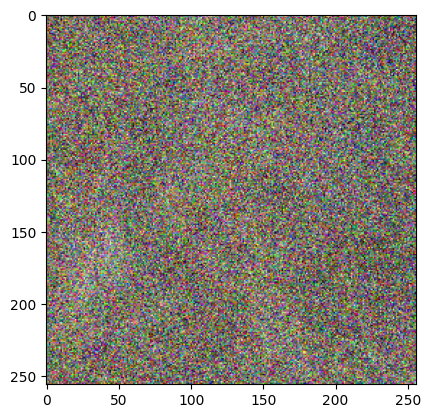

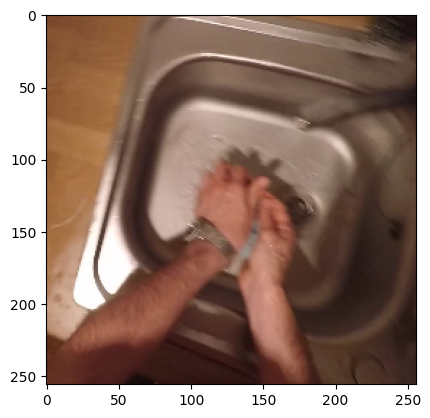

Reconstruction error: 1.05


In [12]:
import matplotlib.pyplot as plt

def decode_features(features):
    with torch.no_grad():
        decoded_video = decoder(features.transpose(1,2).reshape(1, features.size(-1), max_num_frames, 1, 1).cpu())

    return decoded_video

def show_frame(decoded_video, frame_id): # [B,C,T,H,W]
    # unnormalize the features
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    mean, std = torch.tensor(mean)*255, torch.tensor(std)*255
    mean, std = mean.reshape(3,1,1,1), std.reshape(3,1,1,1)
    decoded_video = decoded_video[0]*std + mean # Take the 1st video

    # Show frame
    frame = decoded_video.permute(1,2,3,0)[frame_id]
    plt.imshow(frame.clamp(0, 255).to(torch.int32))
    plt.show()
    

# Patchify the original sample
batch = [s.to(device) for s in sample]
with torch.no_grad():
    original_patches = target_encoder.module.backbone.patch_embed(batch[0])


def reconstruction_error(decoded_vid1, decoded_vid2): # [B,C,T,H,W]
    decoded_vid1 = decoded_vid1.permute(0,2,3,4,1) # [B,T,H,W,C]
    decoded_vid2 = decoded_vid2.permute(0,2,3,4,1)
    diff = torch.abs(decoded_vid1 - decoded_vid2)
    return diff.mean([1,2,3,4]).mean() # average over frames and then over the batch

# Show original image patchify and then decoded
org_patches_decoded = decode_features(original_patches)

# normalized batch: The features are normalized over the emb dim
# So it's better to normalized the patches values
org_patches_decoded = torch.nn.functional.layer_norm(org_patches_decoded, (org_patches_decoded.size(-1),))

frame_id = 5
show_frame(org_patches_decoded, frame_id)
# Show original image
show_frame(batch[0].cpu(), frame_id)
print(f'Reconstruction error: {reconstruction_error(org_patches_decoded,batch[0].cpu()):,.2f}')

The patches do not seem to preserve much information about the actual image.

## Analyzing the target encoder features

/usr/lib/python3.10/contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


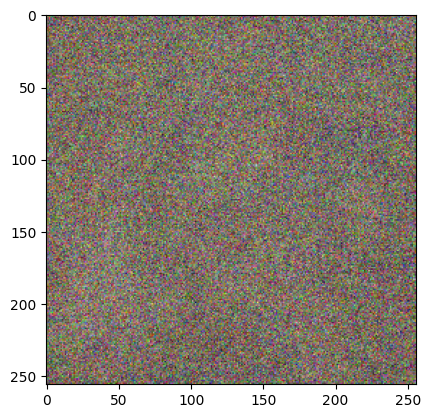

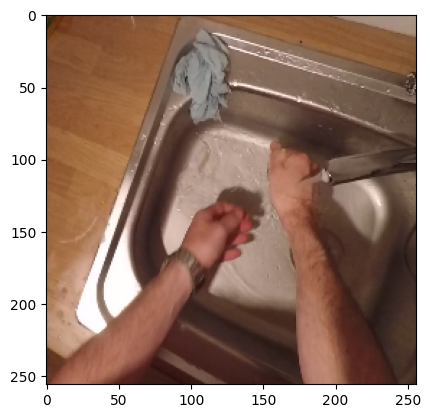

Reconstruction error: 0.86


In [13]:
with torch.no_grad():
    target_encoder_features = target_encoder(batch)
target_encoder_features = target_encoder_features[0].cpu()

# decode the features
decoded = decode_features(target_encoder_features)

frame_id = 0
# Show decoded features
show_frame(decoded, frame_id)
# Show original image
show_frame(batch[0].cpu(), frame_id)
print(f'Reconstruction error: {reconstruction_error(decoded,batch[0].cpu()):,.2f}')

We can see that the target encoder features don't preserve information about the actual image neither.

Similarity of the raw 3d convolution output and the final encoder output in embedding space

In [14]:
torch.abs(torch.nn.functional.layer_norm(target_encoder_features, (1024,)) - torch.nn.functional.layer_norm(original_patches.cpu(), (1024,))).mean(dim=-1).mean()

tensor(0.3057)

The encoder is transforming the data and the features differ from the patches embeddings.

## Analyzing the predictor output

input features of the predictor


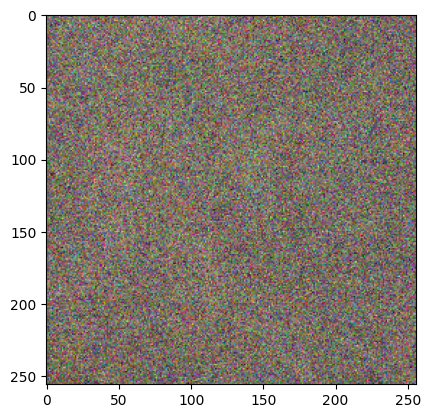

output features of the predictor


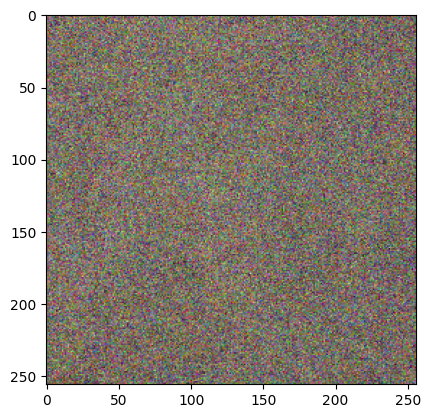

patchified original next image


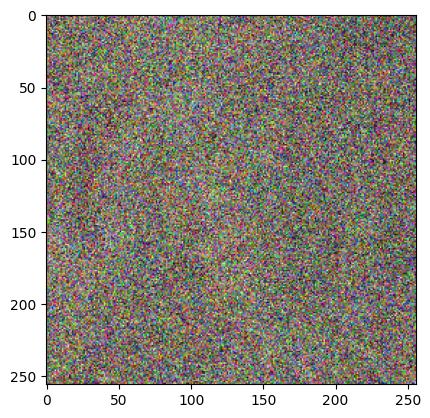

Reconstruction error against the patchified real images (emb space): 0.38
Reconstruction error against the encoded real images (loss objective) (emb space): 0.2277


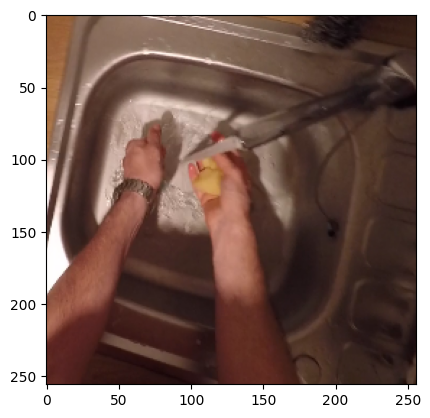

Reconstruction error (pixel space): 0.86


In [15]:
with torch.no_grad():
    context_encoder_features = encoder(batch)
    predicted_features = predictor(context_encoder_features, is_causal=True)
    target_encoder_features = target_encoder(batch)
    

target_encoder_features = target_encoder_features[0].cpu()
predicted_features = predicted_features[0].cpu()

# decode the features
predicted_decoded = decode_features(predicted_features)

target_encoder_features = torch.nn.functional.layer_norm(target_encoder_features,(1024,))[:,1:]
predicted_features = predicted_features[:,:-1]

frame_id = 2
# Show input features of the predictor
print('input features of the predictor')
show_frame(decoded, frame_id)
# Show output features of the predictor
print('output features of the predictor')
show_frame(predicted_decoded, frame_id)
# Show the patchified original next image
print('patchified original next image')
show_frame(org_patches_decoded, frame_id + 1)
print(f'Reconstruction error against the patchified real images (emb space): {torch.abs(predicted_features-torch.nn.functional.layer_norm(original_patches[:,1:].cpu(),(1024,))).mean():,.2f}')
print(f'Reconstruction error against the encoded real images (loss objective) (emb space): {torch.abs(predicted_features-target_encoder_features).mean():,.4f}')

# Show the next original image
show_frame(batch[0].cpu(), frame_id+1)
print(f'Reconstruction error (pixel space): {reconstruction_error(predicted_decoded[:,:,:-1],batch[0].cpu()[:,:,1:]):,.2f}')

The predictor output and the encoder feature are not visually interpretable. However, the prediction loss for this example is in the range observed while training.